In [1]:
from kan import *
import torch
torch.cuda.empty_cache()
import os

In [2]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu" )
print(device)

cuda:3


In [3]:
hust_dataset = torch.load('../Data/HUST_Data_Var2.pt')

/tmp/ipykernel_774606/3860308048.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  hust_dataset = torch.load('../Data/HUST_Data_Var2.pt')


In [4]:
train_loader = hust_dataset['train_loader']
valid_loader = hust_dataset['valid_loader']
test_loader = hust_dataset['test_loader']

In [5]:
import argparse
def get_args():
    parser = argparse.ArgumentParser('Hyper Parameters for HUST dataset')
    parser.add_argument('--model_name',type=str,default='KAN')
    parser.add_argument('--data', type=str, default='HUST', help='XJTU, HUST, MIT, TJU')
    parser.add_argument('--batch_size', type=int, default=512, help='batch size')
    parser.add_argument('--normalization_method', type=str, default='min-max', help='min-max,z-score')

    parser.add_argument('--epochs', type=int, default=200, help='epoch')
    parser.add_argument('--early_stop', type=int, default=20, help='early stop')
    parser.add_argument('--warmup_epochs', type=int, default=30, help='warmup epoch')
    parser.add_argument('--warmup_lr', type=float, default=2e-3, help='warmup lr')
    parser.add_argument('--lr', type=float, default=1e-2, help='base lr')
    parser.add_argument('--final_lr', type=float, default=2e-4, help='final lr')
    parser.add_argument('--lr_F', type=float, default=5e-4, help='lr of F')

    parser.add_argument('--ckpt_path', type=str, default='../Notebooks/ckpt_path/kan_hust_var2/')
    parser.add_argument('--log_dir', type=str, default='logging.txt', help='log dir, if None, do not save')
    parser.add_argument('--save_folder', type=str, default='../Notebooks/results_of_kan/HUST results/kan_fit_1', help='save folder')
    parser.add_argument('--image_folder', type=str, default='../Images/kan_hust_var2/video_img_fit_1', help='save folder')
    parser.add_argument('--save_fig', type=bool, default=True, help='whether to save video image')
    parser.add_argument('--in_vars', type=list, default=[r'$x$', r'$t$'], help='the input variables of solution_u')
    parser.add_argument('--out_vars', type=list, default=[r'$u$'], help='the output variable of solution_u')
    parser.add_argument('--mark', type=str, default='0.0', help='the version of pikan')
    
    args = parser.parse_args([])    # 传入空列表，避免解析 Jupyter 注入的参数
    return args
args = get_args()

In [6]:
import logging
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error
def set_seed(seed):
    if seed is None:
        seed = np.random.randint(1e6)
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed) # 为了禁止hash随机化，使得实验可复现。
    torch.manual_seed(seed) # 为CPU设置随机种子
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed) # 为当前GPU设置随机种子
        torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU，为所有GPU设置随机种子
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

def get_logger(log_name='log.txt'):
    logger = logging.getLogger('mylogger')
    logger.setLevel(level=logging.DEBUG)
    formatter = logging.Formatter('%(asctime)s - function:%(funcName)s - %(levelname)s - %(message)s',datefmt='%Y-%m-%d %H:%M')

    # console = logging.StreamHandler()
    # console.setLevel(logging.INFO)
    # console.setFormatter(formatter)
    # logger.addHandler(console)

    if log_name is not None:
        handler = logging.FileHandler(log_name)
        handler.setLevel(logging.DEBUG)
        handler.setFormatter(formatter)
        logger.addHandler(handler)

    return logger

class AverageMeter(object):
    """Computes and stores the average and current value"""

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def eval_metrix(true_label,pred_label):
    MAE = mean_absolute_error(true_label,pred_label)
    MAPE = mean_absolute_percentage_error(true_label,pred_label)
    MSE = mean_squared_error(true_label,pred_label)
    RMSE = np.sqrt(mean_squared_error(true_label,pred_label))

    return [MAE,MAPE,MSE,RMSE]

In [7]:
from torch.autograd import grad
class LR_Scheduler(object): # 用于调整优化器的学习率
    def __init__(self, optimizer, warmup_epochs, warmup_lr, num_epochs, base_lr, final_lr, iter_per_epoch=1,
                 constant_predictor_lr=False):  # 优化器、预热期的轮数、预热期的学习率、总轮数、基础学习率、最终学习率
        self.base_lr = base_lr
        self.constant_predictor_lr = constant_predictor_lr
        warmup_iter = iter_per_epoch * warmup_epochs
        warmup_lr_schedule = np.linspace(warmup_lr, base_lr, warmup_iter)   # 预热期的学习率序列，线性热身，从warmup_lr线性增加到base_lr
        decay_iter = iter_per_epoch * (num_epochs - warmup_epochs)
        cosine_lr_schedule = final_lr + 0.5 * (base_lr - final_lr) * (
                    1 + np.cos(np.pi * np.arange(decay_iter) / decay_iter)) # 衰减期的余弦学习率序列，余弦退火，从base_lr逐渐下降到final_lr，并且下降的过程是按照余弦函数的形状进行的

        self.lr_schedule = np.concatenate((warmup_lr_schedule, cosine_lr_schedule)) # 完整的学习率序列
        self.optimizer = optimizer
        self.iter = 0
        self.current_lr = 0

    def step(self): # 在每次调用时，根据当前迭代次数为优化器的参数组设置学习率
        for param_group in self.optimizer.param_groups:

            if self.constant_predictor_lr and param_group['name'] == 'predictor':   # 特殊情况，学习率保持不变
                param_group['lr'] = self.base_lr
            else:
                lr = param_group['lr'] = self.lr_schedule[self.iter]    # 学习率调整策略

        self.iter += 1
        self.current_lr = lr
        return lr

    def get_lr(self):
        return self.current_lr

class Model(nn.Module):
    def __init__(self,args):
        super(Model,self).__init__()
        self.args = args
        self.device = device
        if args.save_folder is not None and not os.path.exists(args.save_folder):   # 保存传入的参数
            os.makedirs(args.save_folder)
        if args.image_folder is not None and not os.path.exists(args.image_folder):   # 保存传入的参数
            os.makedirs(args.image_folder)
            os.makedirs(args.image_folder+'/kan')
        self.logger = get_logger(os.path.join(args.save_folder,args.log_dir))
        self._save_args()

        if args.mark == '0.0':
            self.model = KAN(width=[2,4,1], grid=3, k=3, seed=25, ckpt_path=args.ckpt_path + 'kan/',device=self.device)   # 求解偏微分方程解的网络
        else:
            self.model = KAN.loadckpt(args.ckpt_path + 'kan/'+args.mark)   # 求解偏微分方程解的网络

        self.loss_meter = AverageMeter()
        self.loss_func = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(),lr=args.warmup_lr)
        self.scheduler = LR_Scheduler(optimizer=self.optimizer,
                                      warmup_epochs=args.warmup_epochs,
                                      warmup_lr=args.warmup_lr,
                                      num_epochs=args.epochs,
                                      base_lr=args.lr,
                                      final_lr=args.final_lr)

        # 模型的最好参数(the best model)
        self.best_model = None

    def _save_args(self):
        if self.args.log_dir is not None:
            # 中文： 把parser中的参数保存在self.logger中
            # English: save the parameters in parser to self.logger
            self.logger.info("Args:")
            for k, v in self.args.__dict__.items():
                self.logger.critical(f"\t{k}:{v}")    
    
    def clear_logger(self):
        self.logger.removeHandler(self.logger.handlers[0])
        self.logger.handlers.clear()

    def train_one_epoch(self,dataloader):
        self.train()
        self.loss_meter.reset()
        for (x1,_,y1,_) in dataloader:
            x1 = x1.to(self.device)
            y1 = y1.to(self.device)
            y_pred = self.model(x1)
            loss = self.loss_func(y_pred,y1)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            self.loss_meter.update(loss.item())
        return self.loss_meter.avg

    def Valid(self,validloader):
        self.eval()
        self.loss_meter.reset()
        with torch.no_grad():
            for (x1,_,y1,_) in validloader:
                x1 = x1.to(self.device)
                y1 = y1.to(self.device)
                y_pred = self.model(x1)
                loss = self.loss_func(y_pred,y1)
                self.loss_meter.update(loss.item())
        return self.loss_meter.avg

    def Test(self,testloader):
        self.eval()
        self.loss_meter.reset()
        true_label = []
        pred_label = []
        with torch.no_grad():
            for (x1,_,y1,_) in testloader:
                x1 = x1.to(self.device)
                y_pred = self.model(x1)
                true_label.append(y1.cpu().detach().numpy())
                pred_label.append(y_pred.cpu().detach().numpy())
        true_label = np.concatenate(true_label,axis=0)
        pred_label = np.concatenate(pred_label,axis=0)
        return true_label,pred_label

    def Train(self,trainloader,validloader=None,testloader=None):
        min_loss = 100
        early_stop = 0
        best_fit_first = True
        for epoch in range(1,self.args.epochs+1):
            early_stop += 1
            train_loss = self.train_one_epoch(trainloader)
            current_lr = self.scheduler.step()
            info = '[Train] epoch:{:0>3d}, lr:{:.6f}, data loss:{:.6f}'.format(epoch,current_lr,train_loss)
            self.logger.info(info)
            valid_loss = self.Valid(validloader)
            info = '[Valid] epoch:{:0>3d}, data loss:{:.6f}'.format(epoch,valid_loss)
            self.logger.info(info)
            if valid_loss < min_loss and testloader is not None:
                min_loss = valid_loss
                true_label,pred_label = self.Test(testloader)
                [MAE, MAPE, MSE, RMSE] = eval_metrix(pred_label, true_label)
                info = '[Test] MSE: {:.8f}, MAE: {:.6f}, MAPE: {:.6f}, RMSE: {:.6f}'.format(MSE, MAE, MAPE, RMSE)
                self.logger.info(info)
                early_stop = 0
                
                self.best_model = {'kan':self.model.state_dict()}
                
                if best_fit_first:
                    self.model.log_history('best_fit')
                    round = self.model.round
                    state_id = self.model.state_id
                    best_fit_first = False
                else:
                    self.model.saveckpt(args.ckpt_path + 'kan/'+str(round)+'.'+str(state_id))
                if self.args.save_folder is not None:
                    np.save(os.path.join(self.args.save_folder, 'true_label.npy'), true_label)
                    np.save(os.path.join(self.args.save_folder, 'pred_label.npy'), pred_label)
               
            if args.save_fig:
                self.model.plot(folder=args.image_folder+'/kan', in_vars=args.in_vars, out_vars=args.out_vars, title="Step {}".format(epoch))
                plt.savefig(args.image_folder + '/kan/' + str(epoch) + '.jpg', bbox_inches='tight', dpi=200)
                plt.close()
            
            if early_stop > 10:
                info = 'early stop at epoch {}'.format(epoch)
                self.logger.info(info)
                break
        self.clear_logger()
        if self.args.save_folder is not None:
            torch.save(self.best_model,os.path.join(self.args.save_folder,'model.pth'))
            self.model.log_history('fit')


In [31]:
set_seed(25)       
model = Model(args)
model.Train(trainloader=train_loader,validloader=valid_loader,testloader=test_loader)

checkpoint directory created: ../Notebooks/ckpt_path/kan_hust_var2/kan/
saving model version 0.0
saving model version 0.1
saving model version 0.2


In [45]:
args.mark = '0.1'
model = Model(args)
true_label, pred_label = model.Test(testloader=test_loader)
metrics = eval_metrix(pred_label, true_label)
print(f"Metrics for KAN forecast: MAE:{metrics[0]}, MAPE:{metrics[1]}, MSE:{metrics[2]}, RMSE:{metrics[3]}")

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

Metrics for KAN forecast: MAE:0.008438645862042904, MAPE:0.008543774485588074, MSE:9.881227015284821e-05, RMSE:0.009940436109900475


In [33]:
import os
import numpy as np
from PIL import Image  # 用于图片拼接
import moviepy.video.io.ImageSequenceClip

video_name='kan_hust_var2'
fps=10
name = 'kan'
all_image_files = []
image_folder = args.image_folder + '/' + name
files = os.listdir(image_folder)
train_index = []
for file in files:
    if file[0].isdigit() and file.endswith('.jpg'):
        train_index.append(int(file[:-4]))
train_index = np.sort(train_index)
image_files = [image_folder+'/'+str(index)+'.jpg' for index in train_index]
all_image_files += image_files
all_image_files.append(all_image_files[-1])
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(all_image_files, fps=fps)
output_path = "../Videos/"+video_name+'/video_fit_1/'+name+".mp4"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
clip.write_videofile(output_path)

MoviePy - Building video ../Videos/kan_hust_var2/video_fit_1/kan.mp4.
MoviePy - Writing video ../Videos/kan_hust_var2/video_fit_1/kan.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/kan_hust_var2/video_fit_1/kan.mp4


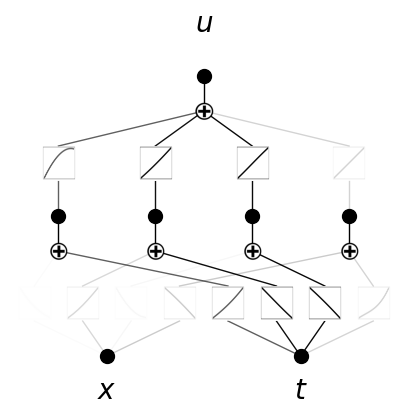

In [35]:
model.model = KAN.loadckpt('../Notebooks/ckpt_path/kan_hust_var2/kan/0.1')
model.model.plot(folder="../Images/kan_hust_var2/paper_img/kan_fit_1/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

saving model version 1.2


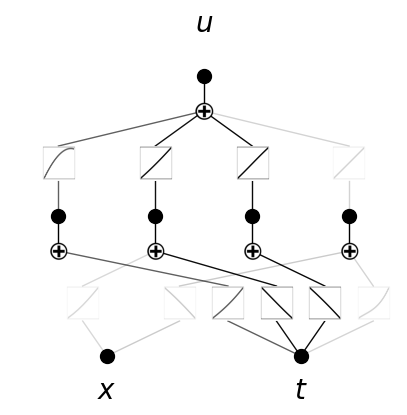

In [36]:
model.model = model.model.prune()
model.model.plot(folder="../Images/kan_hust_var2/paper_img/kan_prune_1/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

In [37]:
args.mark = '1.2'
args.epochs = 100
args.save_folder = '../Notebooks/results_of_kan/HUST results/kan_fit_2'
args.image_folder = '../Images/kan_hust_var2/video_img_fit_2'
model = Model(args)
model.Train(trainloader=train_loader,validloader=valid_loader,testloader=test_loader)

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

saving model version 2.3
saving model version 2.4


In [47]:
args.mark = '2.4'
model = Model(args)
true_label, pred_label = model.Test(testloader=test_loader)
metrics = eval_metrix(pred_label, true_label)
print(f"Metrics for KAN forecast: MAE:{metrics[0]}, MAPE:{metrics[1]}, MSE:{metrics[2]}, RMSE:{metrics[3]}")

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

Metrics for KAN forecast: MAE:0.008379366248846054, MAPE:0.00848296657204628, MSE:9.964984928956255e-05, RMSE:0.009982476942241192


In [39]:
video_name='kan_hust_var2'
fps=10
name = 'kan'
all_image_files = []
image_folder = args.image_folder + '/' + name
files = os.listdir(image_folder)
train_index = []
for file in files:
    if file[0].isdigit() and file.endswith('.jpg'):
        train_index.append(int(file[:-4]))
train_index = np.sort(train_index)
image_files = [image_folder+'/'+str(index)+'.jpg' for index in train_index]
all_image_files += image_files
all_image_files.append(all_image_files[-1])
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(all_image_files, fps=fps)
output_path = "../Videos/"+video_name+'/video_fit_2/'+name+".mp4"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
clip.write_videofile(output_path)

MoviePy - Building video ../Videos/kan_hust_var2/video_fit_2/kan.mp4.
MoviePy - Writing video ../Videos/kan_hust_var2/video_fit_2/kan.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/kan_hust_var2/video_fit_2/kan.mp4


/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

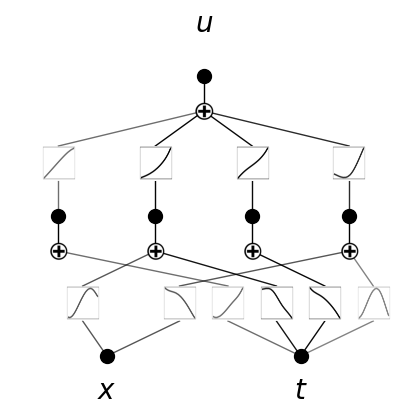

In [48]:
model.model = KAN.loadckpt('../Notebooks/ckpt_path/kan_hust_var2/kan/2.4')
model.model.plot(folder="../Images/kan_hust_var2/paper_img/kan_fit_2/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

In [8]:
add_symbolic('bessel_j0',torch.special.bessel_j0)
add_symbolic('erf',torch.special.erf)
add_symbolic('sinc',torch.special.sinc)
add_symbolic('softmax',lambda x: torch.special.softmax(x, dim=0))
add_symbolic('sigmoid', torch.sigmoid)
add_symbolic('relu',torch.relu)
add_symbolic('cosh',torch.cosh)
add_symbolic('sinh',torch.sinh)
add_symbolic('arcsinh',torch.arcsinh)
add_symbolic('arccosh',torch.arccosh)

In [50]:
model.model.auto_symbolic()

fixing (0,0,0) with 0
fixing (0,0,1) with bessel_j0, r2=0.9998590350151062, c=1
fixing (0,0,2) with 0
fixing (0,0,3) with arcsinh, r2=0.9990500807762146, c=1
fixing (0,1,0) with bessel_j0, r2=0.9975823760032654, c=1
fixing (0,1,1) with sinc, r2=0.9989389181137085, c=1
fixing (0,1,2) with sinh, r2=0.9992799758911133, c=1
fixing (0,1,3) with bessel_j0, r2=0.9997354745864868, c=1
fixing (1,0,0) with arcsinh, r2=0.9995219707489014, c=1
fixing (1,1,0) with sinh, r2=0.9999452233314514, c=1
fixing (1,2,0) with sinh, r2=0.9999796748161316, c=1
fixing (1,3,0) with sinc, r2=0.9985872507095337, c=1
saving model version 3.5


In [51]:
args.mark = '3.5'
args.epochs = 50
args.save_folder = '../Notebooks/results_of_kan/HUST results/kan_fit_3'
args.image_folder = '../Images/kan_hust_var2/video_img_fit_3'
model = Model(args)
model.Train(trainloader=train_loader,validloader=valid_loader,testloader=test_loader)

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

saving model version 4.6
saving model version 4.7


In [9]:
args.mark = '4.7'
model = Model(args)
true_label, pred_label = model.Test(testloader=test_loader)
metrics = eval_metrix(pred_label, true_label)
print(f"Metrics for KAN forecast: MAE:{metrics[0]}, MAPE:{metrics[1]}, MSE:{metrics[2]}, RMSE:{metrics[3]}")

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

Metrics for KAN forecast: MAE:0.00838700495660305, MAPE:0.008505968376994133, MSE:9.974976273952052e-05, RMSE:0.009987480007112026


In [54]:
video_name='kan_hust_var2'
fps=10
name = 'kan'
all_image_files = []
image_folder = args.image_folder + '/' + name
files = os.listdir(image_folder)
train_index = []
for file in files:
    if file[0].isdigit() and file.endswith('.jpg'):
        train_index.append(int(file[:-4]))
train_index = np.sort(train_index)
image_files = [image_folder+'/'+str(index)+'.jpg' for index in train_index]
all_image_files += image_files
all_image_files.append(all_image_files[-1])
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(all_image_files, fps=fps)
output_path = "../Videos/"+video_name+'/video_fit_3/'+name+".mp4"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
clip.write_videofile(output_path)

MoviePy - Building video ../Videos/kan_hust_var2/video_fit_3/kan.mp4.
MoviePy - Writing video ../Videos/kan_hust_var2/video_fit_3/kan.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/kan_hust_var2/video_fit_3/kan.mp4


/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

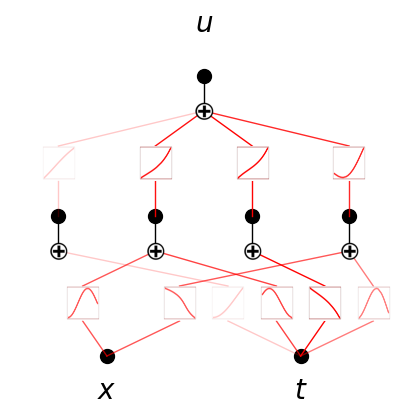

In [58]:
model.model = KAN.loadckpt('../Notebooks/ckpt_path/kan_hust_var2/kan/4.7')
model.model.plot(folder="../Images/kan_hust_var2/paper_img/kan_fit_3/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

In [10]:
formula, variables = model.model.symbolic_formula(var=[r'x', r't'])
print(formula[0])
print(ex_round(formula[0],3))

-0.0106515083462*arcsinh(-3.39193654110886*bessel_j0(-1.00015985965729*t - 4.78615999221802) - 0.813228523931052) + 0.117256283760071*sinc(-0.197640612614439*arcsinh(1.08553028106689 - 3.7564218044281*x) - 0.902106206315516*bessel_j0(7.41463994979858 - 2.47687983512878*t) + 1.30003733881297) - 0.061092235147953*sinh(-0.957296152541971*sinh(-1.01926076412201*t - 0.642309725284576) - 1.44541487008395) - 0.0295738372951746*sinh(-0.654376200686315*bessel_j0(0.779039859771729 - 3.14696002006531*x) - 1.04708377749414*sinc(-0.916739463806152*t - 0.446731925010681) - 0.190649384168418) + 0.875316277146339
-0.011*arcsinh(-3.392*bessel_j0(-1.0*t - 4.786) - 0.813) + 0.117*sinc(-0.198*arcsinh(1.086 - 3.756*x) - 0.902*bessel_j0(7.415 - 2.477*t) + 1.3) - 0.061*sinh(-0.957*sinh(-1.019*t - 0.642) - 1.445) - 0.03*sinh(-0.654*bessel_j0(0.779 - 3.147*x) - 1.047*sinc(-0.917*t - 0.447) - 0.191) + 0.875


In [9]:
def complex_expression_1(input):
    # Unpack inputs
    x, t = input

    # First part of the expression
    Eq = -0.0106515083462*torch.arcsinh(-3.39193654110886*torch.special.bessel_j0(-1.00015985965729*t - 4.78615999221802) - 0.813228523931052) \
    + 0.117256283760071*torch.special.sinc(-0.197640612614439*torch.arcsinh(1.08553028106689 - 3.7564218044281*x) \
    - 0.902106206315516*torch.special.bessel_j0(7.41463994979858 - 2.47687983512878*t) + 1.30003733881297) \
    - 0.061092235147953*torch.sinh(-0.957296152541971*torch.sinh(-1.01926076412201*t - 0.642309725284576) - 1.44541487008395) \
    - 0.0295738372951746*torch.sinh(-0.654376200686315*torch.special.bessel_j0(0.779039859771729 - 3.14696002006531*x) \
    - 1.04708377749414*torch.special.sinc(-0.916739463806152*t - 0.446731925010681) - 0.190649384168418) \
    + 0.875316277146339

    # Return the result as a tensor
    return torch.tensor([Eq])

In [10]:
def complex_expression(input):
    # Unpack inputs
    x, t = input

    # First part of the expression
    Eq = -0.0107*torch.arcsinh(-3.3919*torch.special.bessel_j0(-1.0002*t - 4.7862) - 0.8132) \
    + 0.1173*torch.special.sinc(-0.1976*torch.arcsinh(1.0855 - 3.7564*x) \
    - 0.9021*torch.special.bessel_j0(7.4146 - 2.4769*t) + 1.3) \
    - 0.0611*torch.sinh(-0.9573*torch.sinh(-1.0193*t - 0.6423) - 1.4454) \
    - 0.0296*torch.sinh(-0.6544*torch.special.bessel_j0(0.779 - 3.147*x) \
    - 1.0471*torch.special.sinc(-0.9167*t - 0.4467) - 0.1906) + 0.8753

    # Return the result as a tensor
    return torch.tensor([Eq])

In [11]:
args.mark = '2.4'
model = Model(args)
true_label, pred_label = model.Test(testloader=test_loader)

symbolic_forecast = []
symbolic_forecast1 = []
with torch.no_grad():
    for iter,(x1,_,y1,_) in enumerate(test_loader):
        for i in range(x1.shape[0]):
            input = x1[i]
            symbolic_result = complex_expression(input) 
            symbolic_forecast.append(symbolic_result.cpu().numpy())  
            symbolic_result1 = complex_expression_1(input)  
            symbolic_forecast1.append(symbolic_result1.cpu().numpy())  

symbolic_forecast = np.array(symbolic_forecast)
symbolic_forecast1 = np.array(symbolic_forecast1)

kan_metrics = eval_metrix(true_label, pred_label)
symbolic_metrics = eval_metrix(true_label, symbolic_forecast)
symbolic_metrics1 = eval_metrix(true_label, symbolic_forecast1)

print(f"Metrics for KAN forecast: MAE:{kan_metrics[0]}, MAPE:{kan_metrics[1]}, MSE:{kan_metrics[2]}, RMSE:{kan_metrics[3]}")
print(f"Metrics for Symbolic forecast: MAE:{symbolic_metrics[0]}, MAPE:{symbolic_metrics[1]}, MSE:{symbolic_metrics[2]}, RMSE:{symbolic_metrics[3]}")
print(f"Metrics for Symbolic forecast 1: MAE:{symbolic_metrics1[0]}, MAPE:{symbolic_metrics1[1]}, MSE:{symbolic_metrics1[2]}, RMSE:{symbolic_metrics1[3]}")

viz_folder = '../Notebooks/viz_folder'
if not os.path.exists(viz_folder):
    os.makedirs(viz_folder)
# np.save(os.path.join(viz_folder, 'hust_true_values.npy'), true_label)
np.save(os.path.join(viz_folder, 'hust_kan_model_forecast.npy'), pred_label)
np.save(os.path.join(viz_folder, 'hust_kan_symbolic_forecast.npy'), symbolic_forecast1)

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

Metrics for KAN forecast: MAE:0.008379366248846054, MAPE:0.008479960262775421, MSE:9.964984928956255e-05, RMSE:0.009982476942241192
Metrics for Symbolic forecast: MAE:0.008387872017920017, MAPE:0.008507979102432728, MSE:9.975775901693851e-05, RMSE:0.009987880475819111
Metrics for Symbolic forecast 1: MAE:0.00838700495660305, MAPE:0.008506976068019867, MSE:9.974974818760529e-05, RMSE:0.009987480007112026


image saved at ../Images/kan_hust_var2/paper_img/reality_vs_kan_vs_symbolic_first1643.png


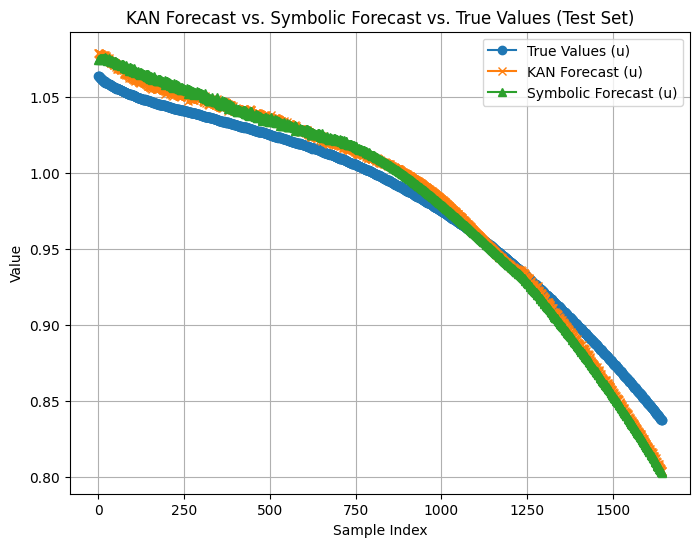

In [66]:
import matplotlib.pyplot as plt

# Set the interval for the samples to plot
interval = 1643

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the KAN forecasts and symbolic forecasts against the true values for id_k1
plt.plot(true_label[:interval], label='True Values (u)', marker='o')
plt.plot(pred_label[:interval], label='KAN Forecast (u)', marker='x')
plt.plot(symbolic_forecast1[:interval], label='Symbolic Forecast (u)', marker='^')
# plt.ylim(0.79, 1.01)
# plt.yticks(np.arange(0.80, 1.01, 0.05))

# Customize the plot
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('KAN Forecast vs. Symbolic Forecast vs. True Values (Test Set)')
plt.legend()
plt.grid(True)

# Save the plot to a specific location
save_path = f'../Images/kan_hust_var2/paper_img/reality_vs_kan_vs_symbolic_first{interval}.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)

# Show the plot
plt.show()

image saved at ../Images/kan_hust_var2/paper_img/reality_vs_kan_vs_symbolic.png


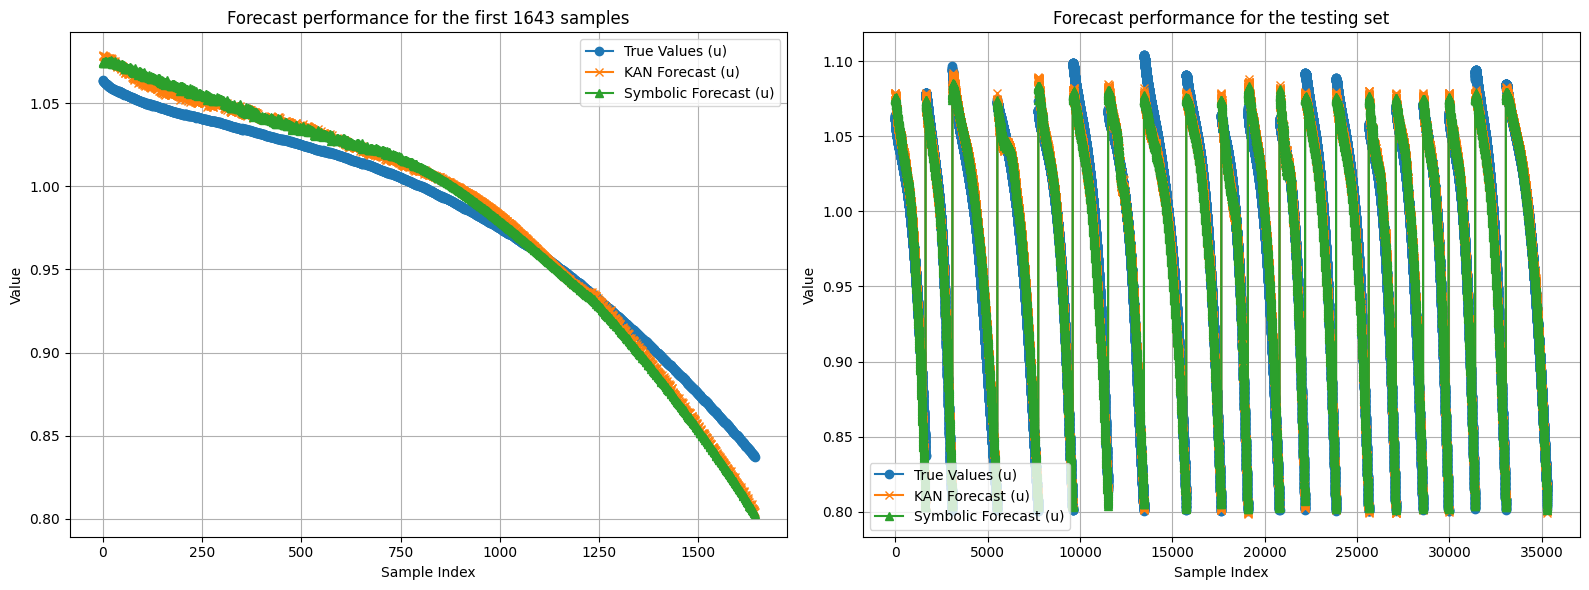

In [67]:
# Set the interval for the first plot (first 50 samples)
interval = 1643

# Create the figure and axes for side-by-side plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot the first interval 
axes[0].plot(true_label[:interval], label='True Values (u)', marker='o')
axes[0].plot(pred_label[:interval], label='KAN Forecast (u)', marker='x')
axes[0].plot(symbolic_forecast1[:interval], label='Symbolic Forecast (u)', marker='^')
# axes[0].set(ylim=(0.79, 1.01),yticks=np.arange(0.80, 1.01, 0.05))

# Set the title and labels for the first plot
axes[0].set_title(f'Forecast performance for the first {interval} samples')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True)

# Plot the second interval (entire dataset)
axes[1].plot(true_label, label='True Values (u)', marker='o')
axes[1].plot(pred_label, label='KAN Forecast (u)', marker='x')
axes[1].plot(symbolic_forecast1, label='Symbolic Forecast (u)', marker='^')
# axes[1].set(ylim=(0.81, 1.04),yticks=np.arange(0.85, 1.00, 0.05))

# Set the title and labels for the second plot
axes[1].set_title('Forecast performance for the testing set')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True)

# Save the plot to a specific location
save_path = '../Images/kan_hust_var2/paper_img/reality_vs_kan_vs_symbolic.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [68]:
import gc
torch.cuda.empty_cache()
gc.collect()

4099